# Imports

In [53]:
import json
import sys
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

## Copy over helper files

In [54]:
source_folder = Path(r"./../CNN")
dest_folder = Path.cwd()

# List of files to copy (specify the 2 files you want)
files_to_copy = ['Constants.py', 'helper_functions.py']  

# Copy the files
for file in files_to_copy:
    source_file = source_folder / file
    dest_file = dest_folder / file
    shutil.copy2(source_file, dest_file)
    print(f"Copied {file} to Appendix\\")

del source_folder, dest_folder, files_to_copy
del file, source_file, dest_file

Copied Constants.py to Appendix\
Copied helper_functions.py to Appendix\


In [55]:
%load_ext autoreload
%autoreload 1
%aimport helper_functions
import helper_functions as HF

%aimport Constants
from Constants import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
DATA_ROOT = Path("./../Dataset Folder/Actual/Concrete Crack Images for Classification/Unseen")
assert DATA_ROOT.exists(), f"Data root does not exist: {DATA_ROOT}"

CNN_CHECKPOINT = Path("./../CNN/Artifacts/custom_cnn_best.pt")
assert CNN_CHECKPOINT.exists(), f"CNN checkpoint does not exist: {CNN_CHECKPOINT}"

In [57]:
HF.seed_everything(seed=SEED)

In [58]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")

torch.set_float32_matmul_precision("high")

GPU: NVIDIA GeForce RTX 3060 Laptop GPU


# Load Checkpoint

In [59]:
checkpoint = torch.load(CNN_CHECKPOINT, map_location=DEVICE, weights_only=False)

unseen_image_paths = []
for path in DATA_ROOT.iterdir():
	if path.is_file() and path.name != ".gitkeep":
		unseen_image_paths.append(path)

unseen_image_paths = sorted(unseen_image_paths)

checkpoint_overview = {
    "model_name": checkpoint["model_name"],
    "dropout": checkpoint["model_kwargs"]["dropout"],
    "image_size": checkpoint.get("image_size", IMAGE_SIZE),
    "best_threshold": checkpoint["best_threshold"],
}

print(json.dumps(checkpoint_overview, indent=2))
print(f"Found {len(unseen_image_paths):,} unseen images.")
print("\nOriginal mixed test-set metrics from training:")
print(json.dumps(checkpoint["test_metrics"], indent=2))

del checkpoint_overview

{
  "model_name": "custom_cnn",
  "dropout": 0.35,
  "image_size": 227,
  "best_threshold": 0.82
}
Found 16,000 unseen images.

Original mixed test-set metrics from training:
{
  "threshold": 0.82,
  "accuracy": 0.9991666666666666,
  "precision": 0.998330550918197,
  "recall": 0.9966666666666667,
  "specificity": 0.9996666666666667,
  "f1": 0.9974979149291077,
  "balanced_accuracy": 0.9981666666666666,
  "auroc": 0.9999741666666667,
  "average_precision": 0.9998689594002448,
  "tp": 598,
  "tn": 2999,
  "fp": 1,
  "fn": 2,
  "loss": 0.003951216086279601
}


# Dataset

In [60]:
DATASET_MEAN, DATASET_STD = HF.compute_mean_std(frame=pd.DataFrame(checkpoint["splits"]["train"]), batch_size=BATCH_SIZE, num_workers=0, device=DEVICE)
print("DATASET_MEAN =", DATASET_MEAN)
print("DATASET_STD  =", DATASET_STD)

cuda <class 'torch.device'>
DATASET_MEAN = tensor([0.7193, 0.6988, 0.6661], device='cuda:0', dtype=torch.float64)
DATASET_STD  = tensor([0.1112, 0.1087, 0.1093], device='cuda:0', dtype=torch.float64)


# Dataset Class, Loaders

In [61]:
eval_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(DATASET_MEAN, DATASET_STD),
    ]
)

In [62]:
class UnseenConcreteCrackDataset(Dataset):
    def __init__(self, image_paths: list[Path], transform: transforms.Compose, label: int = 1):
        self.image_paths = list(image_paths)
        self.transform = transform
        self.label = int(label)

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor, str]:
        path = self.image_paths[index]
        
        with Image.open(path) as image:
            image = image.convert("RGB")
            
            tensor: torch.Tensor = self.transform(image)
            
        label = torch.tensor(self.label, dtype=torch.float32)
        
        return tensor, label, str(path)

In [63]:
@torch.no_grad()
def predict_on_loader(model: nn.Module, loader: DataLoader, device: torch.device) -> tuple[np.ndarray, np.ndarray, list[str]]:
    
    model.eval()
    
    labels_buffer: list[np.ndarray] = []
    probs_buffer: list[np.ndarray] = []
    paths_buffer: list[str] = []

    for images, labels, paths in loader:
        images = images.to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=AMP_ENABLED):
            logits = model(images)

        probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
        labels_buffer.append(labels.numpy().reshape(-1))
        probs_buffer.append(probs)
        paths_buffer.extend(list(paths))

    labels_array = np.concatenate(labels_buffer).astype(np.int64)
    probs_array = np.concatenate(probs_buffer).astype(np.float64)
    
    return labels_array, probs_array, paths_buffer

In [64]:
def summarize_positive_only_holdout(labels: np.ndarray, probs: np.ndarray, threshold: float) -> dict[str, int | float | str]:
    
    labels = np.asarray(labels, dtype=np.int64)
    probs = np.asarray(probs, dtype=np.float64)
    preds = (probs >= threshold).astype(np.int64)

    total_images = int(labels.size)
    true_positives = int(((preds == 1) & (labels == 1)).sum())
    false_negatives = int(((preds == 0) & (labels == 1)).sum())

    return {
        "holdout_name": "Unseen positive-only holdout",
        "ground_truth_class": DISPLAY_NAMES[1],
        "threshold": float(threshold),
        "total_images": total_images,
        "predicted_cracked": true_positives,
        "predicted_uncracked": false_negatives,
        "accuracy": float(true_positives / total_images),
        "recall": float(true_positives / total_images),
        "false_negative_rate": float(false_negatives / total_images),
        "mean_probability_cracked": float(probs.mean()),
        "median_probability_cracked": float(np.median(probs)),
        "min_probability_cracked": float(probs.min()),
        "max_probability_cracked": float(probs.max()),
    }

In [65]:
def build_predictions_frame(paths: list[str], labels: np.ndarray, probs: np.ndarray, threshold: float) -> pd.DataFrame:
    preds = (probs >= threshold).astype(np.int64)
    frame = pd.DataFrame(
        {
            "path": paths,
            "filename": [Path(path).name for path in paths],
            "ground_truth_label": labels,
            "ground_truth": [DISPLAY_NAMES[int(label)] for label in labels],
            "probability_cracked": probs,
            "predicted_label": preds,
            "predicted_class": [DISPLAY_NAMES[int(pred)] for pred in preds],
        }
    )
    frame["is_correct"] = frame["ground_truth_label"] == frame["predicted_label"]
    return frame.sort_values("filename").reset_index(drop=True)

# Custom CNN from Scratch

In [66]:
class ConvBNAct(nn.Module):
    """
    Small reusable convolutional block consisting of Conv2D -> BatchNorm -> SiLU
    """
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

class SqueezeExcitation(nn.Module):
    """
    Squeeze-and-Excitation block, see https://arxiv.org/abs/1709.01507 & https://medium.com/@tahasamavati/squeeze-and-excitation-explained-387b5981f249

    Lets network learn which channels are important and rescale them adaptively
    """
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        hidden = max(8, channels // reduction)
        
        self.layers = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),            # Squeeze
            nn.Conv2d(channels, hidden, kernel_size=1),
            nn.SiLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * self.layers(x)

In [67]:
class ResidualBlock(nn.Module):
	"""
	Learns a deeper transformation while keeping a shortcut connection from input to output
	"""
	def __init__(self, in_channels: int, out_channels: int, stride: int = 1, drop_prob: float = 0.0):
		super().__init__()
		self.conv1 = ConvBNAct(in_channels, out_channels, stride=stride)
		self.conv2 = nn.Sequential(
			nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
			nn.BatchNorm2d(out_channels),
		)
		self.se = SqueezeExcitation(out_channels)

		if drop_prob > 0:
			self.dropout = nn.Dropout2d(drop_prob)
		else:
			self.dropout = nn.Identity()
		
		if stride != 1 or in_channels != out_channels:
			self.shortcut = nn.Sequential(
				nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
				nn.BatchNorm2d(out_channels),
			)
		else:
			self.shortcut = nn.Identity()

		self.activation = nn.SiLU(inplace=True)

	def forward(self, x: torch.Tensor) -> torch.Tensor:
		residual = self.shortcut(x)
		x = self.conv1(x)
		x = self.dropout(x)
		x = self.conv2(x)
		x = self.se(x)
		x = x + residual
		return self.activation(x)

In [68]:
class CustomCrackCNN(nn.Module):
    """
    The fully custom CNN model for crack classificaiton
    """
    def __init__(self, dropout: float = 0.35):
        super().__init__()
        self.features = nn.Sequential(
            ConvBNAct(3, 32, stride=1),
            ConvBNAct(32, 32, stride=1),
            nn.MaxPool2d(kernel_size=2),
            ResidualBlock(32, 64, stride=2, drop_prob=0.05),
            ResidualBlock(64, 128, stride=2, drop_prob=0.08),
            ResidualBlock(128, 256, stride=2, drop_prob=0.10),
            ResidualBlock(256, 384, stride=2, drop_prob=0.12),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(384),
            nn.Dropout(dropout),
            nn.Linear(384, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)

In [69]:
def build_model(model_name: str, dropout: float = 0.35) -> nn.Module:
    if model_name == "custom_cnn":
        return CustomCrackCNN(dropout=dropout)

    raise ValueError(f"Unsupported model_name: {model_name}")

# Model

In [70]:
model = build_model(model_name=checkpoint["model_name"], dropout=checkpoint["model_kwargs"]["dropout"]).to(device=DEVICE)

model.load_state_dict(state_dict=checkpoint["state_dict"])

threshold = checkpoint["best_threshold"]

unseen_dataset = UnseenConcreteCrackDataset(image_paths=unseen_image_paths, transform=eval_transform, label=1)

unseen_loader = DataLoader(unseen_dataset, 
						   batch_size=BATCH_SIZE, 
						   shuffle=False, 
						   num_workers=NUM_WORKERS,
						   persistent_workers=(NUM_WORKERS > 0),
						   pin_memory=(DEVICE.type == "cuda"))

In [71]:
unseen_labels, unseen_probs, unseen_paths = predict_on_loader(model, unseen_loader, DEVICE)

unseen_summary = summarize_positive_only_holdout(unseen_labels, unseen_probs, threshold)

unseen_predictions_df = build_predictions_frame(unseen_paths, unseen_labels, unseen_probs, threshold)

In [72]:
summary_table = pd.DataFrame(
    {
        "metric": list(unseen_summary.keys()),
        "value": list(unseen_summary.values()),
    }
)
display(summary_table)

,metric,value
0,holdout_name,Unseen positive-only holdout
1,ground_truth_class,Cracked
2,threshold,0.82
3,total_images,16000
4,predicted_cracked,15948
5,predicted_uncracked,52
6,accuracy,0.99675
7,recall,0.99675
8,false_negative_rate,0.00325
9,mean_probability_cracked,0.995987


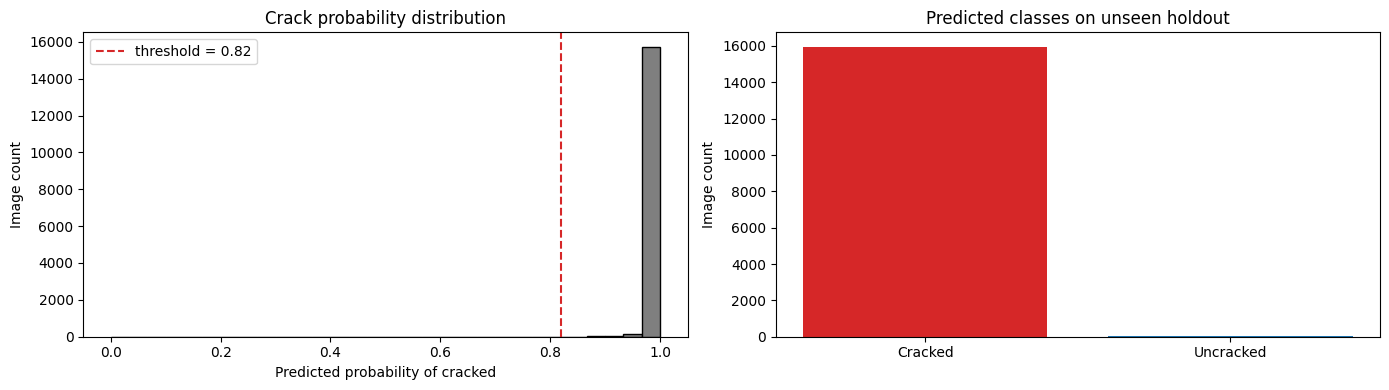

In [73]:
prediction_counts = unseen_predictions_df["predicted_class"].value_counts().reindex([DISPLAY_NAMES[1], DISPLAY_NAMES[0]], fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(unseen_predictions_df["probability_cracked"], bins=30, color="tab:gray", edgecolor="black")
axes[0].axvline(threshold, color="tab:red", linestyle="--", label=f"threshold = {threshold:.2f}")
axes[0].set_title("Crack probability distribution")
axes[0].set_xlabel("Predicted probability of cracked")
axes[0].set_ylabel("Image count")
axes[0].legend()

axes[1].bar(prediction_counts.index, prediction_counts.values, color=["tab:red", "tab:blue"])
axes[1].set_title("Predicted classes on unseen holdout")
axes[1].set_ylabel("Image count")

fig.tight_layout()
plt.show()
            

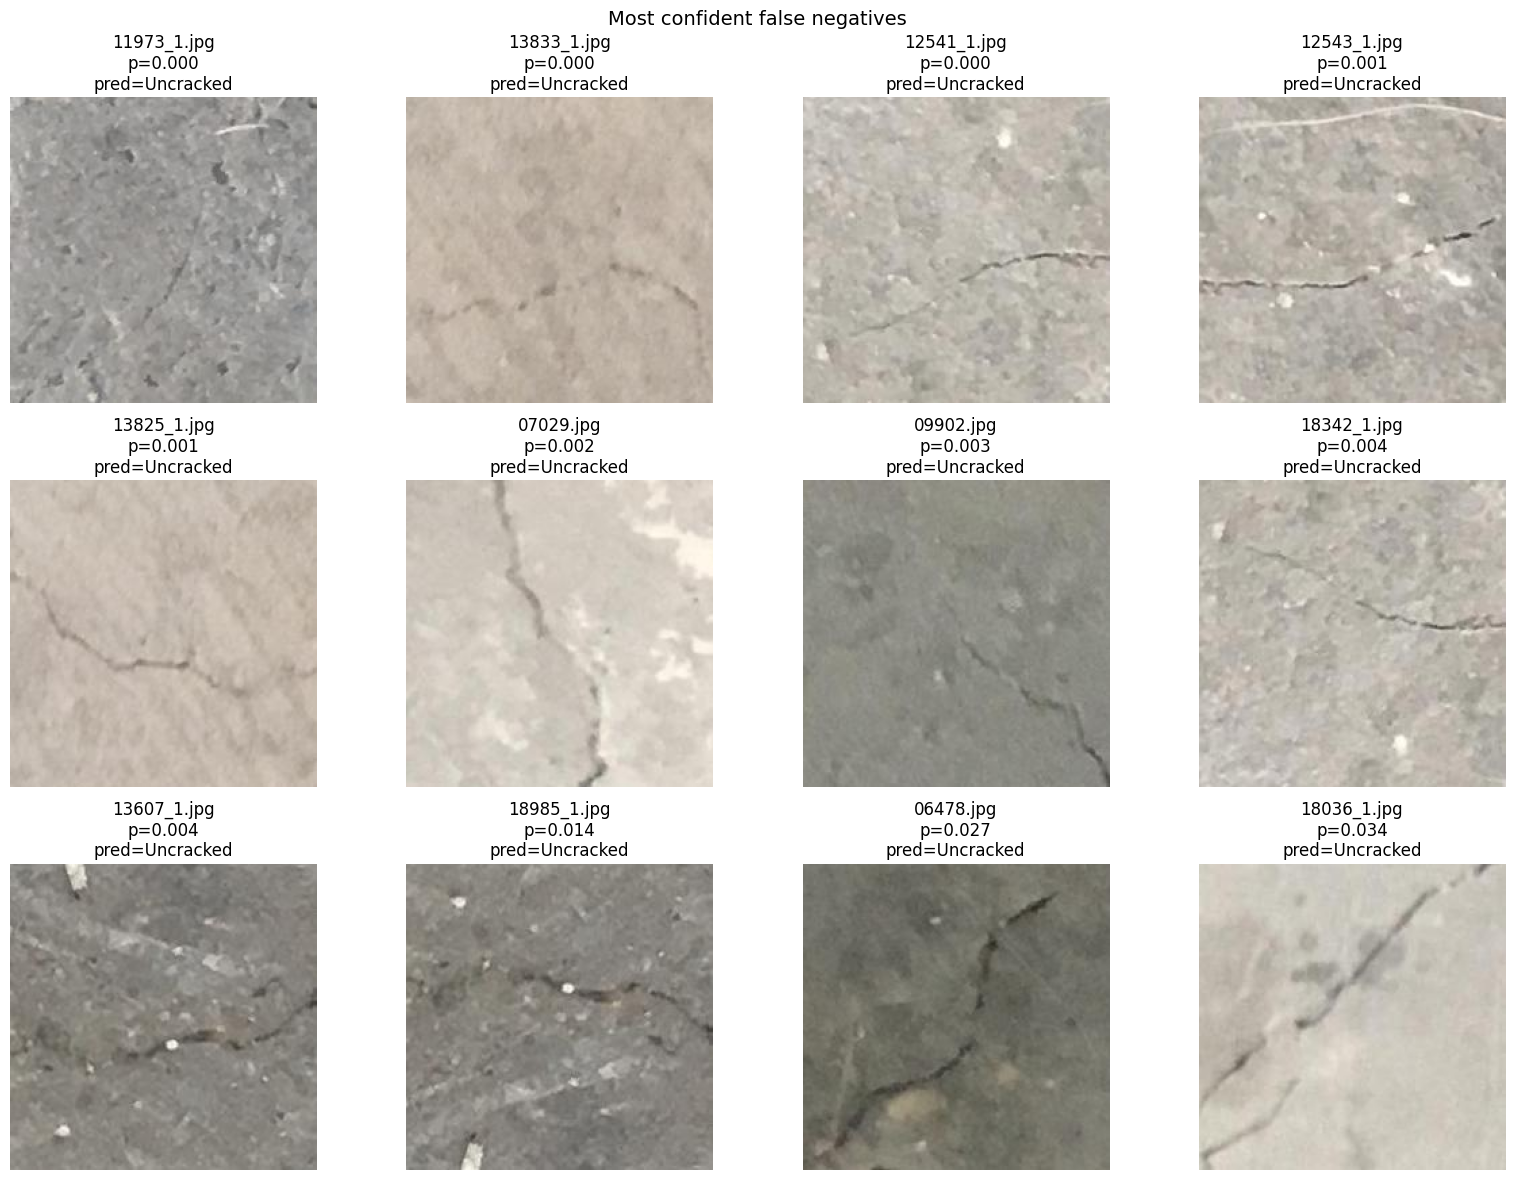

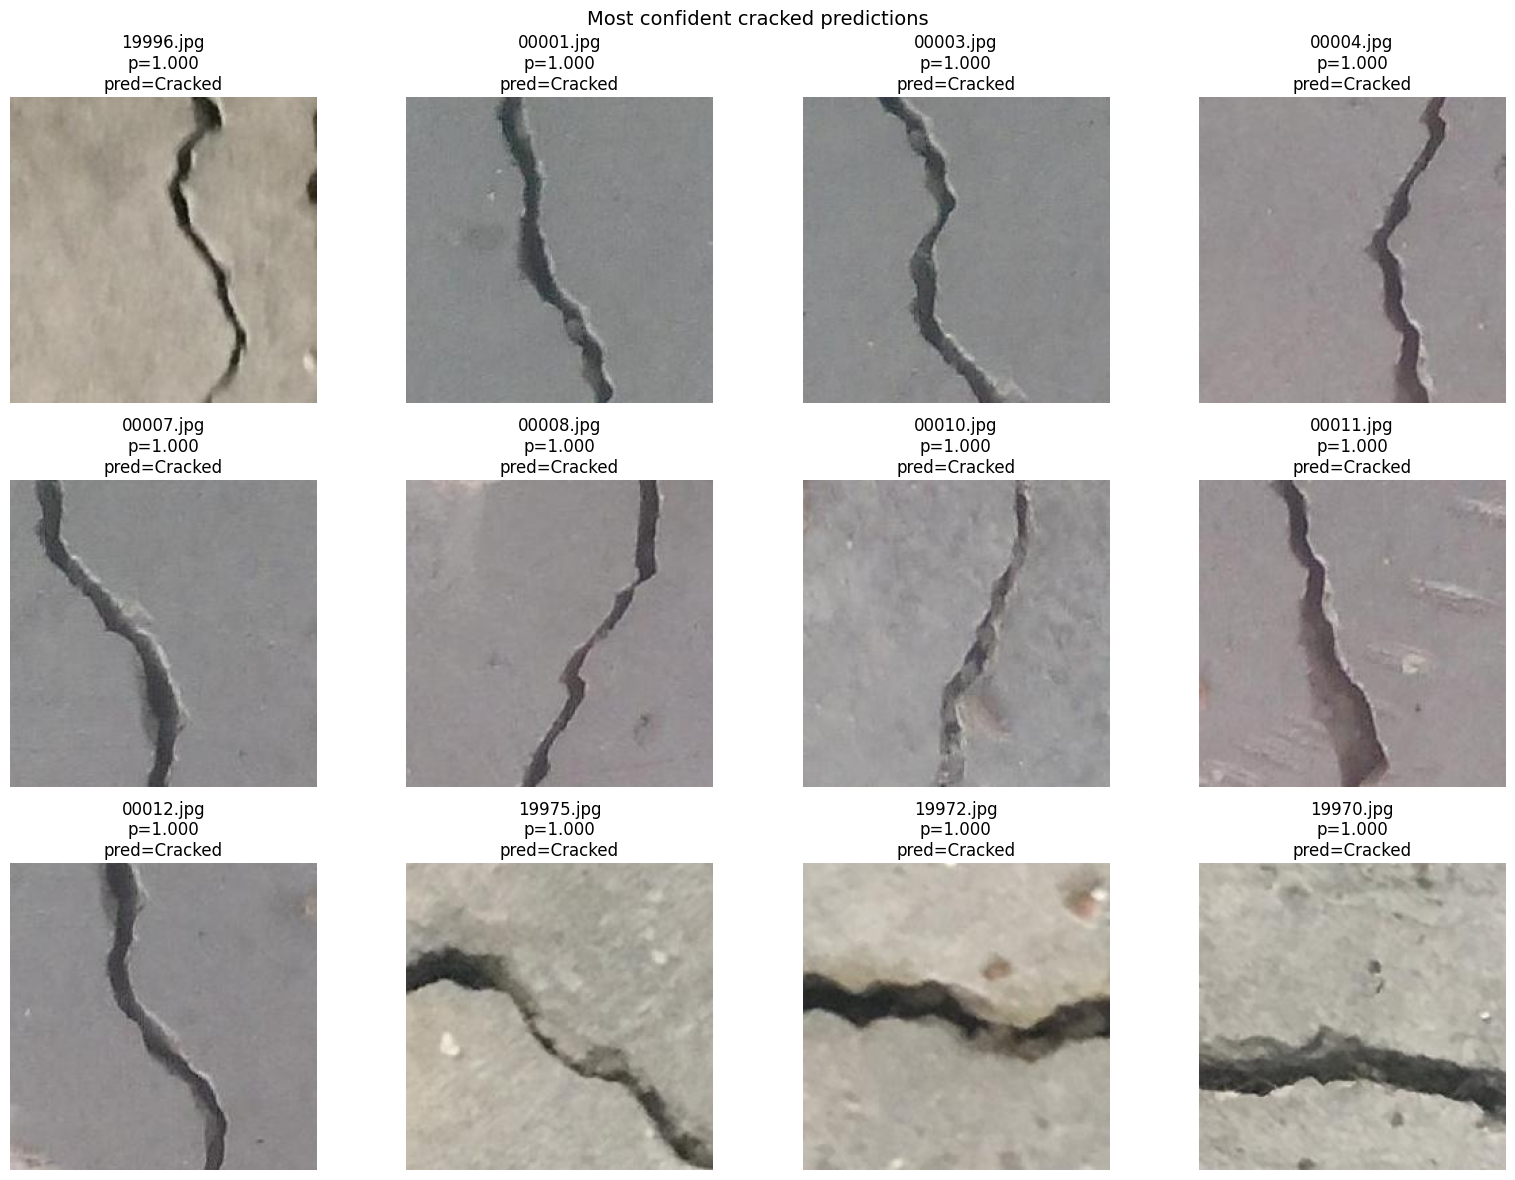

In [74]:
def show_examples(frame: pd.DataFrame, predicted_class: str, top_k: int = 12, ascending: bool = False) -> None:
    subset = frame.loc[frame["predicted_class"] == predicted_class].copy()
    if subset.empty:
        print(f"No images were predicted as {predicted_class.lower()}.")
        return

    subset = subset.sort_values("probability_cracked", ascending=ascending).head(top_k).reset_index(drop=True)
    columns = min(4, len(subset))
    rows = int(np.ceil(len(subset) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows))
    axes = np.atleast_1d(axes).ravel()

    if predicted_class == DISPLAY_NAMES[0]:
        title = "Most confident false negatives"
    else:
        title = "Most confident cracked predictions"

    for ax, (_, row) in zip(axes, subset.iterrows()):
        with Image.open(row["path"]) as image:
            ax.imshow(image.convert("RGB"))
        ax.set_title(
            f"{row['filename']}\np={row['probability_cracked']:.3f}\npred={row['predicted_class']}"
        )
        ax.axis("off")

    for ax in axes[len(subset):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()


show_examples(unseen_predictions_df, DISPLAY_NAMES[0], top_k=12, ascending=True)
show_examples(unseen_predictions_df, DISPLAY_NAMES[1], top_k=12, ascending=False)
            